# Plots and Visualizations

This notebook demonstrates how to create forest plots and other visualizations from analysis results.

In [16]:
import pandas as pd
import numpy as np
from pyMyriad import AnalysisTree
from pyMyriad.plots import forest_plot, distribution_plot

In [17]:
# Create sample data and run analysis
np.random.seed(42)
df = pd.DataFrame(
    {
        "Gender": np.random.choice(["M", "F"], 200),
        "Country": np.random.choice(["US", "UK", "Canada"], 200),
        "Age": np.random.randint(18, 70, 200),
        "Income": np.random.normal(50000, 15000, 200),
    }
)

atree = (
    AnalysisTree()
    .split_by("df.Gender")
    .summarize_by(
        mean_income=lambda df: np.mean(df.Income),
        std_income=lambda df: np.std(df.Income)
    )
    .split_by("df.Country")
    .analyze_by(
        mean_income=lambda df: np.mean(df.Income),
        std_income=lambda df: np.std(df.Income),
    )
)

result = atree.run(df)

## Basic Forest Plot

Create a forest plot showing point estimates with error bars.

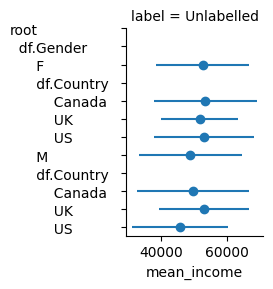

In [18]:
# Plot mean income with standard error bars
forest_plot(result, x="mean_income", x_err="std_income")

## Forest Plot with Color Mapping

Use colors to represent different split levels.

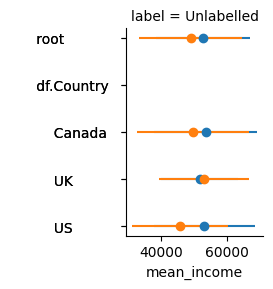

In [19]:
# Color by Gender
forest_plot(result, x="mean_income", x_err="std_income", col="df.Gender")

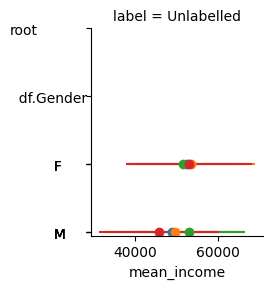

In [20]:
# Color by Country
forest_plot(result, x="mean_income", x_err="std_income", col="df.Country")

## Forest Plot with Faceting

horizontal facets correspond to different analysis labels. This allows to compare groups with different analysis side by side.

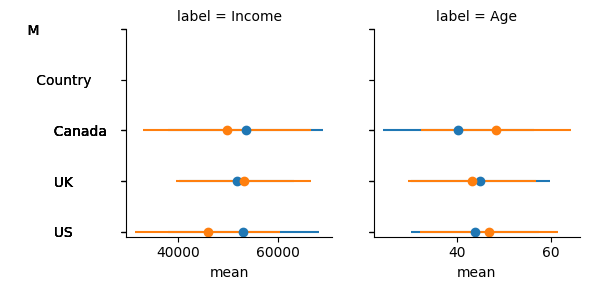

In [ ]:
atree = (
    AnalysisTree()
    .split_by("df.Gender")
    .split_by("df.Country")
    .analyze_by(
        mean=lambda df: np.mean(df.Income),
        std=lambda df: np.std(df.Income),
        label="Income"
    )
    .analyze_by(
        mean=lambda df: np.mean(df.Age),
        std=lambda df: np.std(df.Age),
        label="Age"
    )
)

result = atree.run(df)

# Facet by Gender - one panel per gender
forest_plot(result, x="mean", x_err="std", col="df.Gender")

## Customizing Plot Appearance

Add jittering and custom styling.

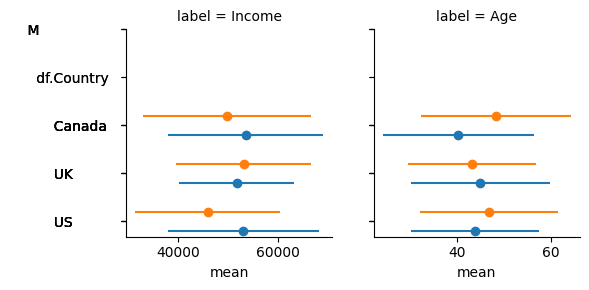

In [ ]:
# Add jittering to avoid overlapping points
forest_plot(result, x="mean", x_err="std", col="df.Gender", jitter=True)


# Distribution Plot

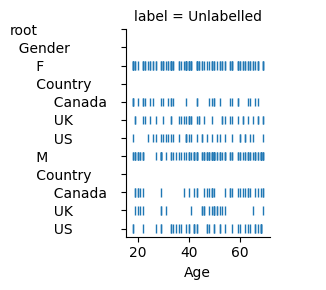

In [ ]:
distribution_plot(result, x="Age")